# Wrapper-Based Feature Selection

Applying wrapper-based feature selection techniques — Exhaustive Feature Selector (EFS) and Sequential (Forward) Feature Selector — on the Iris and Boston Housing datasets.

## Exhaustive Feature Selector (EFS) — Iris Dataset

EFS tests every possible combination of features (up to `max_features`) and picks the subset with the best cross-validated score — the most thorough but most computationally expensive wrapper method.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from mlxtend.feature_selection import SequentialFeatureSelector as mlxtend_SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.feature_selection import SequentialFeatureSelector as sklearn_SFS

df = pd.read_csv('https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [19]:
lr = LogisticRegression(max_iter=1000)

sel = EFS(lr, max_features=4, scoring='accuracy', cv=5)
model = sel.fit(df.iloc[:, :4], df['species'])

print("Best score:", model.best_score_)
print("Best features:", model.best_feature_names_)

Features: 15/15

Best score: 0.9733333333333334
Best features: ('sepal_length', 'sepal_width', 'petal_length', 'petal_width')


In [20]:
### Visualizing All Subset Scores

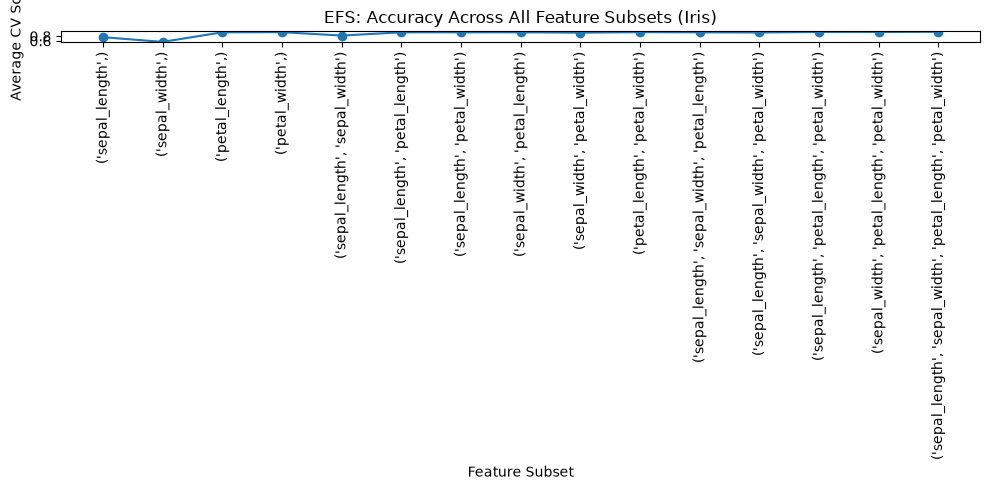

In [21]:
metric_df = pd.DataFrame.from_dict(model.get_metric_dict()).T

plt.figure(figsize=(10, 5))
plt.plot([str(k) for k in metric_df['feature_names']], metric_df['avg_score'], marker='o')
plt.xticks(rotation=90)
plt.xlabel("Feature Subset")
plt.ylabel("Average CV Score")
plt.title("EFS: Accuracy Across All Feature Subsets (Iris)")
plt.tight_layout()
plt.show()

## Exhaustive Feature Selector — Boston Housing (Regression)

Switching to a regression problem with more features (13), letting us compare a baseline model against one selected via EFS.

In [22]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [23]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df['medv'], test_size=0.2, random_state=1)

print(X_train.shape)
print(X_test.shape)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

(404, 13)
(102, 13)


In [24]:
model = LinearRegression()

print("training:", np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='r2')))
print("testing:", np.mean(cross_val_score(model, X_test, y_test, cv=5, scoring='r2')))

training: 0.7025123301096213
testing: 0.6514899901155403


### Running EFS (Capped at max_features=8)

Full exhaustive search across all 13 features (2¹³ = 8,192 combinations) would take a very long time to run locally. Capping at 8 features (2⁸ = 256 combinations) still demonstrates the exhaustive search approach clearly while keeping runtime reasonable.

In [25]:
lr = LinearRegression()

exh = EFS(lr, max_features=8, scoring='r2', cv=10, print_progress=True, n_jobs=-1)
sel = exh.fit(X_train, y_train)

print("Best score:", sel.best_score_)
print("Best features (indices):", sel.best_feature_names_)

Features: 7098/7098

Best score: 0.6732209837441918
Best features (indices): ('0', '1', '4', '5', '7', '8', '10', '12')


### Adjusted R² — Accounting for Number of Features

Adjusted R² penalizes for adding more features, giving a fairer comparison across subsets of different sizes (plain R² almost always increases with more features, even unhelpful ones).

In [26]:
def adjust_r2(r2, num_examples, num_features):
    coef = (num_examples - 1) / (num_examples - num_features - 1)
    return 1 - (1 - r2) * coef

metric_df = pd.DataFrame.from_dict(sel.get_metric_dict()).T
metric_df['observations'] = 404
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x: len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'], metric_df['observations'], metric_df['num_features'])

metric_df.sort_values('adjusted_r2', ascending=False).head(10)

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
6213,"(0, 1, 4, 5, 7, 8, 10, 12)","[0.8572957382107632, 0.589077330932257, 0.4575...",0.673221,"(0, 1, 4, 5, 7, 8, 10, 12)",0.090466,0.121805,0.040602,404,8,0.666603
6913,"(1, 4, 5, 7, 8, 9, 10, 12)","[0.8432767626627041, 0.5888284937385716, 0.450...",0.671074,"(1, 4, 5, 7, 8, 9, 10, 12)",0.088212,0.118769,0.03959,404,8,0.664412
4454,"(0, 1, 4, 5, 7, 10, 12)","[0.8644372676619264, 0.5785298588555712, 0.434...",0.670181,"(0, 1, 4, 5, 7, 10, 12)",0.100698,0.135581,0.045194,404,7,0.664351
6218,"(0, 1, 4, 5, 7, 10, 11, 12)","[0.8699808379270653, 0.5713744330330839, 0.405...",0.670935,"(0, 1, 4, 5, 7, 10, 11, 12)",0.106635,0.143575,0.047858,404,8,0.66427
6583,"(0, 4, 5, 7, 8, 9, 10, 12)","[0.8543879630596144, 0.6085252868819078, 0.451...",0.670534,"(0, 4, 5, 7, 8, 9, 10, 12)",0.090024,0.121209,0.040403,404,8,0.663861
6086,"(0, 1, 3, 4, 5, 7, 10, 12)","[0.8492916602479955, 0.5403792128663958, 0.464...",0.669929,"(0, 1, 3, 4, 5, 7, 10, 12)",0.102666,0.13823,0.046077,404,8,0.663244
5426,"(1, 4, 5, 7, 10, 11, 12)","[0.8503557152965698, 0.5785421533286683, 0.406...",0.668726,"(1, 4, 5, 7, 10, 11, 12)",0.101477,0.13663,0.045543,404,7,0.66287
6585,"(0, 4, 5, 7, 8, 10, 11, 12)","[0.8580171200720262, 0.5979227135597418, 0.418...",0.668951,"(0, 4, 5, 7, 8, 10, 11, 12)",0.096691,0.130187,0.043396,404,8,0.662246
6842,"(1, 3, 4, 5, 7, 10, 11, 12)","[0.8370272118232467, 0.5407012463024772, 0.437...",0.66862,"(1, 3, 4, 5, 7, 10, 11, 12)",0.102866,0.138501,0.046167,404,8,0.661909
5960,"(0, 1, 2, 4, 5, 7, 10, 12)","[0.8639571032980703, 0.573459243364367, 0.4266...",0.668558,"(0, 1, 2, 4, 5, 7, 10, 12)",0.101397,0.136523,0.045508,404,8,0.661845


### Performance with Selected Features vs. Baseline

In [27]:
X_train_sel = sel.transform(X_train)
X_test_sel = sel.transform(X_test)

model = LinearRegression()

print("training:", np.mean(cross_val_score(model, X_train_sel, y_train, cv=5, scoring='r2')))
print("testing:", np.mean(cross_val_score(model, X_test_sel, y_test, cv=5, scoring='r2')))

training: 0.6977266409851475
testing: 0.6975179736713015


## Forward Selection (mlxtend)

Unlike EFS's brute-force approach, Forward Selection starts with zero features and greedily adds one at a time — the feature that most improves the score at each step — until no more improvement is found or `k_features='best'` is reached. Much faster than exhaustive search, though not guaranteed to find the global best subset.

In [28]:
data = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

X = data.drop("medv", axis=1)
y = data['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

model = LinearRegression()
print("training:", np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='r2')))
print("testing:", np.mean(cross_val_score(model, X_test, y_test, cv=5, scoring='r2')))

training: 0.7025123301096213
testing: 0.6514899901155403


In [29]:
lr = LinearRegression()

sfs = mlxtend_SFS(lr, k_features='best', forward=True, floating=False, scoring='r2', cv=5)
sfs.fit(X_train, y_train)

print("Selected feature indices:", sfs.k_feature_idx_)

Selected feature indices: (0, 1, 4, 5, 7, 8, 9, 10, 11, 12)


### Adjusted R² and Selection Progress

In [30]:
metric_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
metric_df['observations'] = 404
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x: len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'], metric_df['observations'], metric_df['num_features'])

metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
1,"(12,)","[0.5472998394577442, 0.49002001493399727, 0.53...",0.538451,"(12,)",0.032755,0.025485,0.012742,404,1,0.537303
2,"(5, 12)","[0.6330856272904802, 0.5779812120755248, 0.586...",0.613259,"(5, 12)",0.034066,0.026505,0.013252,404,2,0.61133
3,"(5, 10, 12)","[0.7215896884753015, 0.6288372046797153, 0.633...",0.661012,"(5, 10, 12)",0.04259,0.033136,0.016568,404,3,0.65847
4,"(5, 10, 11, 12)","[0.725877216548624, 0.6342604286872172, 0.6558...",0.667383,"(5, 10, 11, 12)",0.039611,0.030819,0.01541,404,4,0.664048
5,"(5, 7, 10, 11, 12)","[0.7440756174774326, 0.6473449858158778, 0.614...",0.671496,"(5, 7, 10, 11, 12)",0.055057,0.042836,0.021418,404,5,0.667369
6,"(4, 5, 7, 10, 11, 12)","[0.7554472741494642, 0.6695521143038106, 0.653...",0.68562,"(4, 5, 7, 10, 11, 12)",0.047626,0.037054,0.018527,404,6,0.680869
7,"(1, 4, 5, 7, 10, 11, 12)","[0.754884343390746, 0.6798073590310516, 0.6621...",0.6913,"(1, 4, 5, 7, 10, 11, 12)",0.042762,0.03327,0.016635,404,7,0.685844
8,"(0, 1, 4, 5, 7, 10, 11, 12)","[0.7678201537729974, 0.6827004362205138, 0.671...",0.695442,"(0, 1, 4, 5, 7, 10, 11, 12)",0.048774,0.037948,0.018974,404,8,0.689274
9,"(0, 1, 4, 5, 7, 8, 10, 11, 12)","[0.7746648196407366, 0.6850585456872309, 0.683...",0.703763,"(0, 1, 4, 5, 7, 8, 10, 11, 12)",0.04762,0.03705,0.018525,404,9,0.696996
10,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7769593921905563, 0.6884741223718951, 0.702...",0.710033,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)",0.046075,0.035848,0.017924,404,10,0.702654


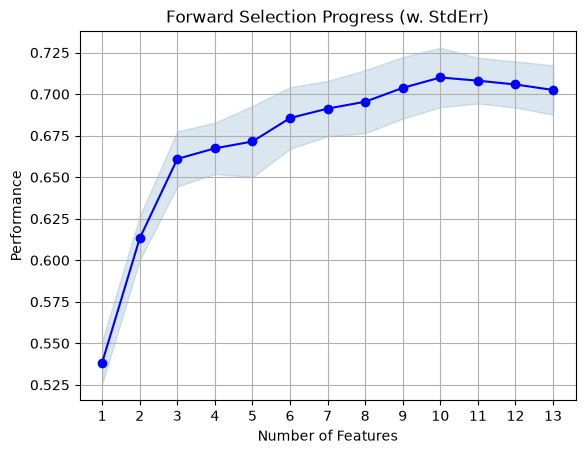

In [31]:
fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_err')
plt.title('Forward Selection Progress (w. StdErr)')
plt.grid()
plt.show()

In [32]:
X_train_sel = sfs.transform(X_train)
X_test_sel = sfs.transform(X_test)

model = LinearRegression()

print("training:", np.mean(cross_val_score(model, X_train_sel, y_train, cv=5, scoring='r2')))
print("testing:", np.mean(cross_val_score(model, X_test_sel, y_test, cv=5, scoring='r2')))
print("Shape:", X_train_sel.shape)

training: 0.7100327839218561
testing: 0.7205819296124482
Shape: (404, 10)


## Forward Selection via sklearn (Comparison)

sklearn's own `SequentialFeatureSelector` offers similar forward-selection functionality with a simpler API — useful when you want a fixed number of features rather than searching for the "best" automatically.

In [33]:
sfs2 = sklearn_SFS(model,
                    n_features_to_select=5,
                    direction='forward',
                    scoring='r2',
                    n_jobs=-1,
                    cv=5)
sfs2 = sfs2.fit(X_train, y_train)

selected_indices = np.arange(X.shape[1])[sfs2.support_]
print("Selected feature indices:", selected_indices)
print("Selected feature names:", X.columns[selected_indices].tolist())

Selected feature indices: [ 5  7 10 11 12]
Selected feature names: ['rm', 'dis', 'ptratio', 'b', 'lstat']


## Summary

| Method | Dataset | Features Selected | Testing R² |
|---|---|---|---|
| Baseline (all features) | Boston Housing | 13 | 0.65 |
| EFS (capped at 8) | Boston Housing | 8 | 0.70 |
| Forward Selection (mlxtend) | Boston Housing | 10 | 0.72 |
| Forward Selection (sklearn) | Boston Housing | 5 | — |

**Key takeaway**: Wrapper methods directly optimize for model performance (unlike filter methods, which use statistical properties independent of any model). EFS guarantees the best subset within its search space but doesn't scale well; Forward Selection is much faster and, in this case, actually found a better-performing subset — showing greedy search isn't always worse in practice, especially when exhaustive search must be capped for runtime reasons.